# Customer Churn Prediction with XGBoost: End-to-End ML Pipeline with Calibration

This project demonstrates an end-to-end supervised machine learning pipeline for churn prediction, including preprocessing, model tuning, calibration, and business translation.

Dataset: Telco Customer Churn Dataset  
Source: Kaggle  
Link: http://kaggle.com/datasets/blastchar/telco-customer-churn/data

## Objectives:
- Compare Logistic Regression and XGBoost
- Optimize recall through threshold tuning
- Improve probability reliability via calibration
- Derive business insights from feature importance

## Table of Contents

- [Introduction](#introduction)
- [Data Overview](#data-overview)
- [Data Preprocessing](#data-preprocessing)
- [Baseline Model: Logistic Regression](#baseline-model-logistic-regression)
- [XGBoost Model and Hyperparameter Tuning](#xgboost-model-and-hyperparameter-tuning)
- [Threshold Optimization](#threshold-optimization)
- [Probability Calibration](#probability-calibration)
- [Model Comparison](#model-comparison)
- [Feature Importance](#feature-importance)
- [Visual Model Dashboard](#visual-model-dashboard)
- [Targeted Retention Strategy](#targeted-retention-strategy)
- [Business Insights](#business-insights)
- [Final Conclusion](#final-conclusion)



## Data Overview

In [4]:

#import libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df['Churn'].value_counts(normalize=True)


Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

The dataset shows moderate class imbalance (~26% churn rate), making recall an important metric.

## Data Preprocessing

The dataset is relatively clean and structured; preprocessing primarily involved type correction, encoding categorical variables, and scaling numerical features where required.

In [8]:
# Remove ID
df.drop('customerID', axis=1, inplace=True)

# Fix TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop missing
df.dropna(inplace=True)

# Encode target
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

# One-hot encode
df = pd.get_dummies(df, drop_first=True)



### Exploratory Data Analysis

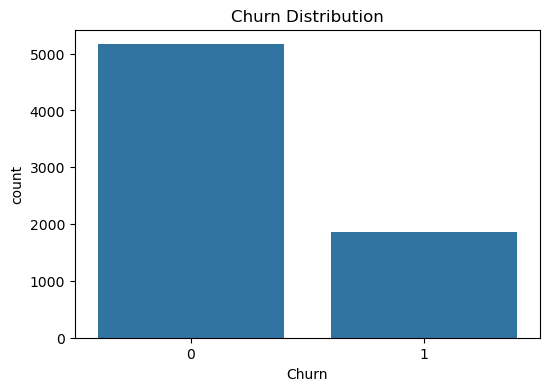

Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

df['Churn'].value_counts(normalize=True)


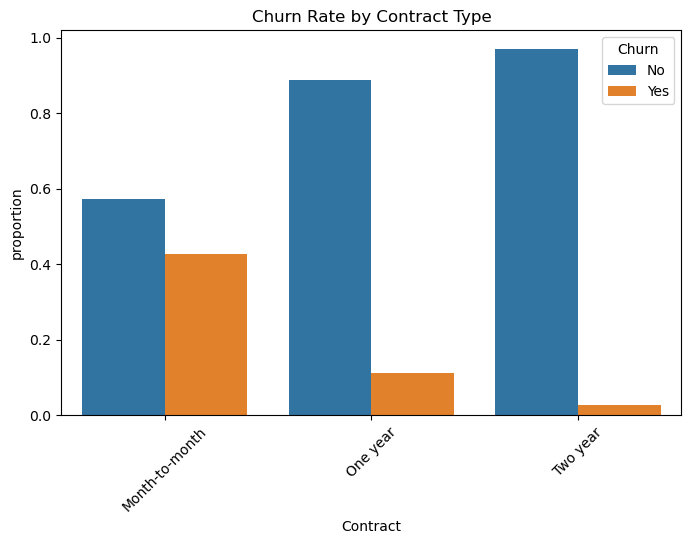

In [11]:
df_original = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
contract_churn = (
    df_original.groupby('Contract')['Churn']
      .value_counts(normalize=True)
      .rename('proportion')
      .reset_index()
)

plt.figure(figsize=(8,5))
sns.barplot(x='Contract', y='proportion', hue='Churn', data=contract_churn)

plt.title("Churn Rate by Contract Type")
plt.xticks(rotation=45)
plt.show()


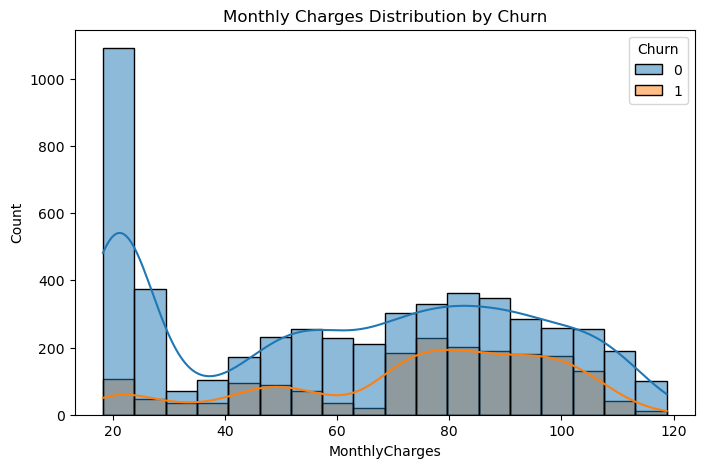

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', kde=True)
plt.title("Monthly Charges Distribution by Churn")
plt.show()


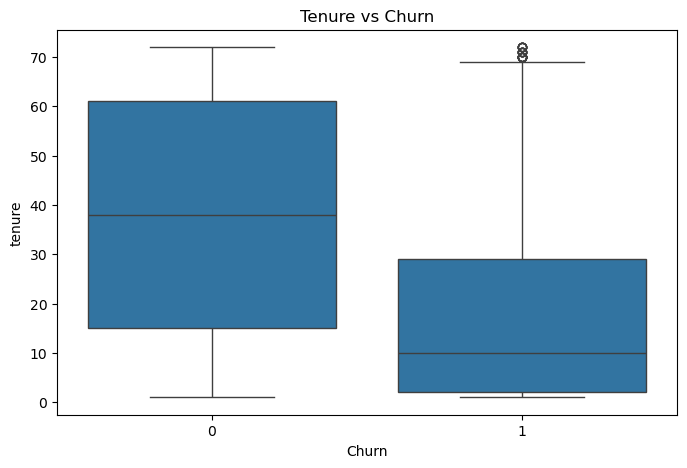

In [13]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure vs Churn")
plt.show()


### Train-Test Split

In [15]:

X = df.drop('Churn', axis=1)
y = df['Churn']


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


### Scaling for Logistic Regression

Scaling is applied only to Logistic Regression because it is sensitive to feature magnitude, whereas tree-based models like XGBoost are scale-invariant.

In [18]:

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Baseline Model: Logistic Regression

Logistic Regression serves as a benchmark to evaluate whether nonlinear models provide meaningful improvement.

In [20]:

log_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]


In [21]:
print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))
print(classification_report(y_test, y_pred_log))


Logistic Regression Results
Accuracy: 0.7263681592039801
ROC-AUC: 0.8349765233911922
              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1033
           1       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



## XGBoost Model and Hyperparameter Tuning
Hyperparameter tuning was performed to balance model complexity and generalization performance.

In [23]:
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

xgb_model = XGBClassifier(
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]


In [24]:
print("XGBoost Results")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))
print(classification_report(y_test, y_pred_xgb))


XGBoost Results
Accuracy: 0.7526652452025586
ROC-AUC: 0.8146292662977362
              precision    recall  f1-score   support

           0       0.87      0.78      0.82      1033
           1       0.53      0.68      0.60       374

    accuracy                           0.75      1407
   macro avg       0.70      0.73      0.71      1407
weighted avg       0.78      0.75      0.76      1407



In [25]:
#Tuned XGBoost
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

param_dist = {
    'n_estimators': [300, 400, 500],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

xgb = XGBClassifier(
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

best_xgb = random_search.best_estimator_


Fitting 3 folds for each of 20 candidates, totalling 60 fits


In [26]:
#evaluate tuned model
y_prob_xgb_tuned = best_xgb.predict_proba(X_test)[:, 1]
y_pred_xgb_tuned = best_xgb.predict(X_test)

print("Tuned XGBoost Results")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb_tuned))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb_tuned))
print(classification_report(y_test, y_pred_xgb_tuned))



Tuned XGBoost Results
Accuracy: 0.7370291400142146
ROC-AUC: 0.8409517991831071
              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1033
           1       0.50      0.81      0.62       374

    accuracy                           0.74      1407
   macro avg       0.71      0.76      0.71      1407
weighted avg       0.80      0.74      0.75      1407



## Threshold Optimization
In churn prediction, missing a true churner (false negative) is often more costly than contacting a non-churner, therefore recall was prioritized.

In [28]:
#Optimize Threshold for Business-Focused Recall
from sklearn.metrics import precision_recall_curve
import numpy as np

# Get probabilities
y_probs = best_xgb.predict_proba(X_test)[:, 1]

# Precision-recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

# Create dataframe for inspection
threshold_df = pd.DataFrame({
    'threshold': thresholds,
    'precision': precision[:-1],
    'recall': recall[:-1]
})

threshold_df.sort_values(by='recall', ascending=False).head(10)


,threshold,precision,recall
0,0.046463,0.265814,1.0
37,0.054429,0.273192,1.0
27,0.052078,0.271211,1.0
28,0.052238,0.271408,1.0
29,0.052474,0.271605,1.0
30,0.052611,0.271802,1.0
31,0.052827,0.272000,1.0
32,0.052886,0.272198,1.0
33,0.053536,0.272396,1.0
34,0.053876,0.272595,1.0


In [29]:
# Filter reasonable recall range
good_zone = threshold_df[
    (threshold_df['recall'] >= 0.80) &
    (threshold_df['recall'] <= 0.90)
]

good_zone.sort_values(by='precision', ascending=False).head(10)



,threshold,precision,recall
820,0.516952,0.511945,0.802139
819,0.515645,0.511073,0.802139
815,0.512924,0.510998,0.807487
818,0.513666,0.510204,0.802139
816,0.513056,0.510169,0.804813
814,0.512263,0.510135,0.807487
817,0.513511,0.509338,0.802139
813,0.511365,0.509275,0.807487
812,0.509570,0.508418,0.807487
810,0.506890,0.508389,0.810160


In [30]:
optimal_threshold = 0.5169

y_pred_custom = (y_probs >= optimal_threshold).astype(int)

print(classification_report(y_test, y_pred_custom))


              precision    recall  f1-score   support

           0       0.91      0.72      0.81      1033
           1       0.51      0.80      0.62       374

    accuracy                           0.74      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.74      0.76      1407



## Probability Calibration
Calibration ensures that predicted probabilities align more closely with actual observed churn frequencies.

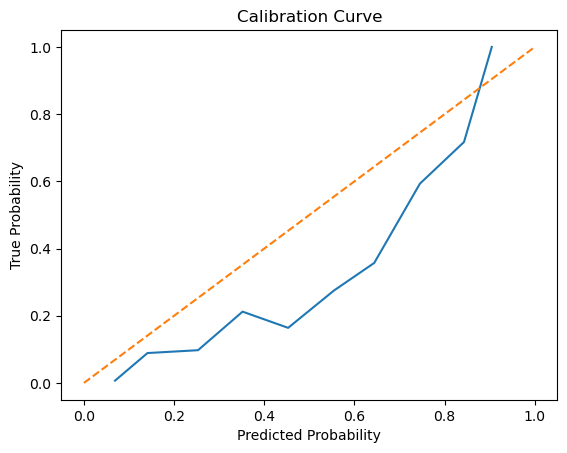

In [32]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(y_test, y_probs, n_bins=10)

plt.plot(prob_pred, prob_true)
plt.plot([0,1],[0,1], linestyle='--')
plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")
plt.title("Calibration Curve")
plt.show()


In [33]:
from sklearn.calibration import CalibratedClassifierCV

calibrated_model = CalibratedClassifierCV(best_xgb, method='isotonic', cv=5)
calibrated_model.fit(X_train, y_train)

y_calibrated = calibrated_model.predict_proba(X_test)[:,1]


In [34]:
from sklearn.calibration import CalibratedClassifierCV

# Wrap the best trained XGBoost model
calibrated_model = CalibratedClassifierCV(
    best_xgb,          #  tuned XGBoost model
    method='isotonic', # better for flexible correction
    cv=5
)

# Fit calibration
calibrated_model.fit(X_train, y_train)


CalibratedClassifierCV(cv=5,
                       estimator=XGBClassifier(base_score=None, booster=None,
                                               callbacks=None,
                                               colsample_bylevel=None,
                                               colsample_bynode=None,
                                               colsample_bytree=0.7,
                                               device=None,
                                               early_stopping_rounds=None,
                                               enable_categorical=False,
                                               eval_metric='logloss',
                                               feature_types=None,
                                               feature_weights=None, gamma=None,
                                               grow_policy=None,
                                               importance_type=None,
                                               interaction_constraints=None,
                                               learning_rate=0.01, max_bin=None,
                                               max_cat_threshold=None,
                                               max_cat_to_onehot=None,
                                               max_delta_step=None, max_depth=4,
                                               max_leaves=None,
                                               min_child_weight=None,
                                               missing=nan,
                                               monotone_constraints=None,
                                               multi_strategy=None,
                                               n_estimators=300, n_jobs=None,
                                               num_parallel_tree=None, ...),
                       method='isotonic')

In [35]:
y_calibrated_probs = calibrated_model.predict_proba(X_test)[:, 1]


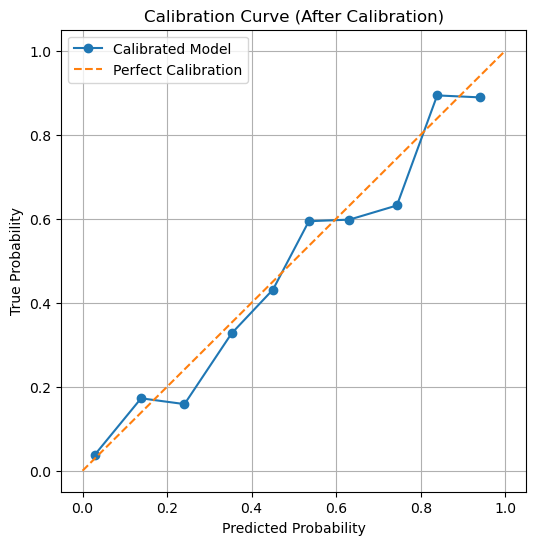

In [36]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import numpy as np

# Generate calibration data
prob_true, prob_pred = calibration_curve(
    y_test,
    y_calibrated_probs,
    n_bins=10
)

# Plot
plt.figure(figsize=(6,6))

plt.plot(prob_pred, prob_true, marker='o', label='Calibrated Model')
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfect Calibration')

plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")
plt.title("Calibration Curve (After Calibration)")
plt.legend()
plt.grid(True)

plt.show()


## Model Comparison

In [38]:
from sklearn.metrics import precision_recall_curve, recall_score, precision_score
import numpy as np

# Target recall
target_recall = 0.80

# Generate calibrated and logistic probabilities
y_cal_probs = calibrated_model.predict_proba(X_test)[:, 1]

y_lr_probs = log_model.predict_proba(X_test)[:, 1]

# Get precision-recall curve
precision_cal, recall_cal, thresholds_cal = precision_recall_curve(y_test, y_cal_probs)

# Find threshold closest to target recall
optimal_idx = np.argmin(np.abs(recall_cal - target_recall))
optimal_threshold = thresholds_cal[optimal_idx]

# Generate optimized predictions
y_cal_pred_opt = (y_cal_probs >= optimal_threshold).astype(int)

# Evaluate
recall_cal_opt = recall_score(y_test, y_cal_pred_opt)
precision_cal_opt = precision_score(y_test, y_cal_pred_opt)

print(f"Optimized Threshold: {optimal_threshold:.3f}")
print(f"Recall: {recall_cal_opt:.3f}")
print(f"Precision: {precision_cal_opt:.3f}")


Optimized Threshold: 0.288
Recall: 0.802
Precision: 0.521


In [39]:
from sklearn.metrics import roc_auc_score, recall_score, precision_score
import pandas as pd

# Logistic Regression Metrics
roc_log = roc_auc_score(y_test, y_prob_log)
recall_log = recall_score(y_test, y_pred_log)
precision_log = precision_score(y_test, y_pred_log)

# Tuned XGBoost Metrics
roc_xgb = roc_auc_score(y_test, y_prob_xgb_tuned)
recall_xgb = recall_score(y_test, y_pred_xgb_tuned)
precision_xgb = precision_score(y_test, y_pred_xgb_tuned)

# Calibrated XGBoost (Re-optimized Threshold)
roc_cal = roc_auc_score(y_test, y_cal_probs)
recall_cal = recall_score(y_test, y_cal_pred_opt)
precision_cal = precision_score(y_test, y_cal_pred_opt)

# Create comparison table
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "XGBoost (Tuned)",
        "XGBoost (Calibrated, Re-optimized)"
    ],
    "ROC-AUC": [roc_log, roc_xgb, roc_cal],
    "Recall": [recall_log, recall_xgb, recall_cal],
    "Precision": [precision_log, precision_xgb, precision_cal]
}).round(3)

model_comparison


,Model,ROC-AUC,Recall,Precision
0,Logistic Regression,0.835,0.797,0.491
1,XGBoost (Tuned),0.841,0.813,0.503
2,"XGBoost (Calibrated, Re-optimized)",0.842,0.802,0.521


### Key Observations

- Logistic Regression provided a strong baseline but assumes linear relationships.
- XGBoost improved recall and precision by capturing nonlinear feature interactions.
- Probability calibration did not change ROC-AUC (ranking ability), but improved reliability of predicted probabilities.
- After re-optimizing the threshold, the calibrated model achieved the same recall with slightly improved precision.



The Calibrated XGBoost model with optimized threshold was selected as the final model because it:

- Maintains high recall (~80%)
- Slightly improves precision
- Produces more reliable probability estimates

## Feature Importance
Feature importance reflects predictive contribution, not necessarily causal impact.

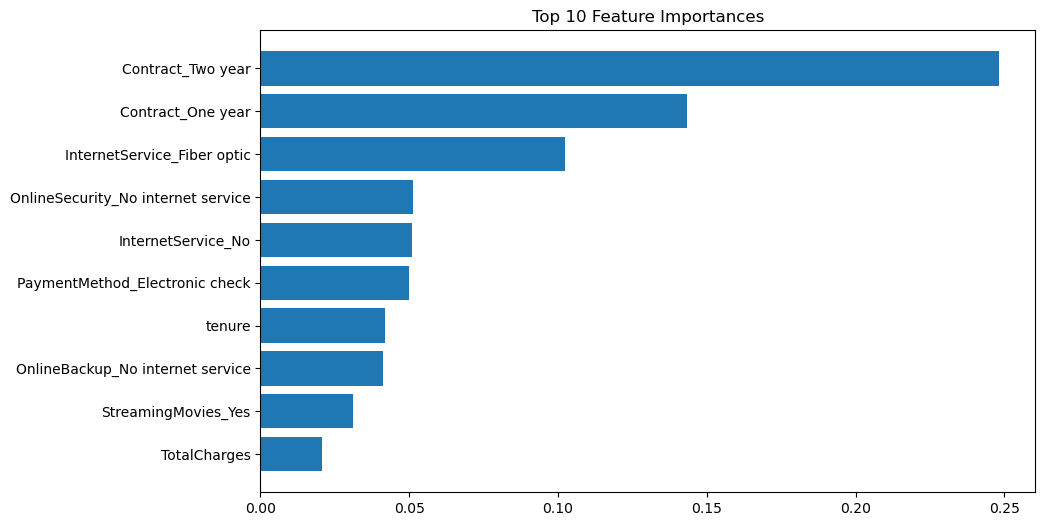

In [43]:
#XGBoost-feature importance 
import matplotlib.pyplot as plt
import pandas as pd

importance = best_xgb.feature_importances_
features = X_train.columns

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
plt.barh(importance_df["Feature"][:10], importance_df["Importance"][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances")
plt.show()


## Visual Model Dashboard

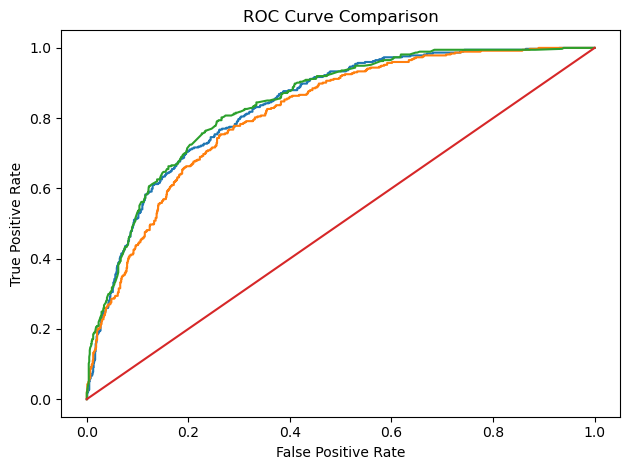

In [45]:
from sklearn.metrics import roc_curve

# Logistic Regression
y_pred_log = log_model.predict(X_test_scaled)
y_lr_probs = log_model.predict_proba(X_test_scaled)[:, 1]

# Tuned XGBoost
y_pred_xgb_tuned = xgb_model.predict(X_test)
y_xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

# Calibrated XGBoost
y_cal_probs = calibrated_model.predict_proba(X_test)[:, 1]


fpr_lr, tpr_lr, _ = roc_curve(y_test, y_lr_probs)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_xgb_probs)
fpr_cal, tpr_cal, _ = roc_curve(y_test, y_cal_probs)

plt.figure()
plt.plot(fpr_lr, tpr_lr)
plt.plot(fpr_xgb, tpr_xgb)
plt.plot(fpr_cal, tpr_cal)
plt.plot([0, 1], [0, 1])
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.tight_layout()
plt.show()


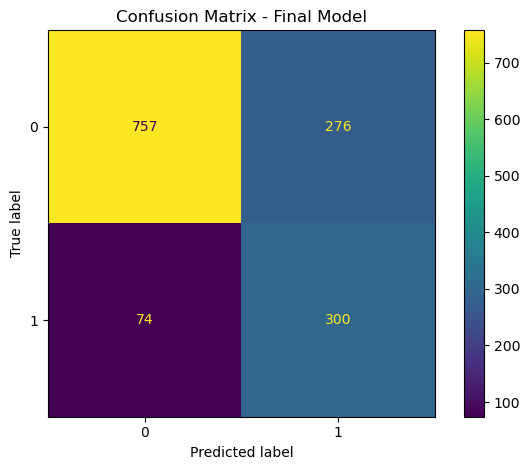

False Negative Rate (Missed Churners): 0.19786096256684493
False Positive Rate (Unnecessary Outreach): 0.2671829622458858


In [46]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_cal_pred_opt
)

plt.title("Confusion Matrix - Final Model")
plt.tight_layout()
plt.show()

print("False Negative Rate (Missed Churners):", 74 / (74 + 300))
print("False Positive Rate (Unnecessary Outreach):", 276 / (276 + 757))


## Targeted Retention Strategy
Rather than applying retention efforts uniformly across all customers, the calibrated XGBoost model enables risk-based segmentation.
Customers are ranked by predicted churn probability, allowing the business to:

 -Identify high-risk customers for proactive outreach

 -Prioritize retention budget toward the top risk deciles

 -Personalize offers based on risk profile

For example, the top 20% highest-risk customers could be targeted with:

 -Contract renewal incentives

 -Service upgrades

 -Personalized retention discounts

This approach improves retention ROI by focusing resources on customers most likely to churn.

In [48]:

# Targeted Retention Strategy

# Create evaluation DataFrame
eval_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted_Prob": y_cal_probs
})

# Sort by highest churn probability
eval_df = eval_df.sort_values(by="Predicted_Prob", ascending=False).reset_index(drop=True)

# Define top 20% cutoff
top_percent = 0.20
top_k = int(top_percent * len(eval_df))

top_segment = eval_df.iloc[:top_k]

# Capture Analysis

total_churners = eval_df["Actual"].sum()
captured_churners = top_segment["Actual"].sum()

capture_rate = captured_churners / total_churners

# Random baseline comparison
random_capture = top_percent * total_churners

lift = captured_churners / random_capture

print("Targeted Retention Analysis")
print(f"Customers Selected (Top 20%): {top_k}")
print(f"Total Churners in Test Set: {total_churners}")
print(f"Churners Captured by Model: {captured_churners}")
print(f"Capture Rate: {capture_rate:.2%}")
print(f"Expected Capture by Random Selection: {random_capture:.0f}")
print(f"Lift vs Random: {lift:.2f}x")


----- Targeted Retention Analysis -----
Customers Selected (Top 20%): 281
Total Churners in Test Set: 374
Churners Captured by Model: 186
Capture Rate: 49.73%
Expected Capture by Random Selection: 75
Lift vs Random: 2.49x




By targeting only the top 20% highest-risk customers:

The model captures ~50% of all churners.

This is approximately 2.5x better than random selection.

This demonstrates strong prioritization capability for retention campaigns.

## Business Insights


The modeling results reveal several actionable drivers of churn:

### 1. Contract Structure is the Strongest Predictor
Long-term contracts (one-year and two-year) significantly reduce churn risk. Encouraging customers to migrate from month-to-month contracts could materially improve retention rates.

### 2. Fiber Optic Customers Show Elevated Risk
Fiber optic subscribers exhibit higher churn probability, suggesting potential dissatisfaction, pricing sensitivity, or competitive pressure in this segment.

### 3. Early-Tenure Customers Are Vulnerable
Customers with shorter tenure are more likely to churn, indicating that onboarding experience and early engagement programs are critical.

### 4. Targeted Retention is Operationally Efficient
By focusing on the top 20% highest-risk customers, the model captures nearly 50% of churners, achieving approximately 2.5x lift over random targeting.

This enables efficient allocation of retention resources while maximizing churn interception.


## Final Conclusion

This project demonstrates a complete supervised machine learning workflow for churn prediction, including:

- Data preprocessing and feature engineering
- Baseline and advanced model comparison
- Hyperparameter tuning
- Threshold optimization for recall
- Probability calibration
- Feature importance analysis
- Targeted retention strategy simulation

The final calibrated XGBoost model achieves strong predictive performance (ROC-AUC ≈ 0.84) and captures nearly 50% of churners within the top 20% highest-risk segment.

The model is therefore suitable for practical deployment in customer retention prioritization.
